In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df1 = pd.read_csv("data/api_data_aadhar_biometric_0_500000.csv")
df2 = pd.read_csv("data/api_data_aadhar_biometric_500000_1000000.csv")
df3 = pd.read_csv("data/api_data_aadhar_biometric_1000000_1500000.csv")
df4 = pd.read_csv("data/api_data_aadhar_biometric_1500000_1861108.csv")

df = pd.concat([df1, df2, df3, df4], ignore_index=True)
df.shape

(1861108, 6)

In [4]:
df.head()

,date,state,district,pincode,bio_age_5_17,bio_age_17_
0,01-03-2025,Haryana,Mahendragarh,123029,280,577
1,01-03-2025,Bihar,Madhepura,852121,144,369
2,01-03-2025,Jammu and Kashmir,Punch,185101,643,1091
3,01-03-2025,Bihar,Bhojpur,802158,256,980
4,01-03-2025,Tamil Nadu,Madurai,625514,271,815


In [5]:
df.columns

Index(['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_'], dtype='object')

In [6]:
df.duplicated().sum()

np.int64(94896)

In [7]:
df.isnull().sum()

date            0
state           0
district        0
pincode         0
bio_age_5_17    0
bio_age_17_     0
dtype: int64

In [8]:
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y', errors='coerce')
df['date'].dtype

dtype('<M8[ns]')

In [9]:
df.isnull().sum()

date            0
state           0
district        0
pincode         0
bio_age_5_17    0
bio_age_17_     0
dtype: int64

In [10]:
df['total_bio_updates'] = df['bio_age_5_17'] + df['bio_age_17_']
df[['bio_age_5_17', 'bio_age_17_', 'total_bio_updates']].head()

,bio_age_5_17,bio_age_17_,total_bio_updates
0,280,577,857
1,144,369,513
2,643,1091,1734
3,256,980,1236
4,271,815,1086


In [11]:
state_updates = (
    df.groupby('state')['total_bio_updates']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)
state_updates.head(10)

,state,total_bio_updates
0,Uttar Pradesh,9577735
1,Maharashtra,9226139
2,Madhya Pradesh,5923771
3,Bihar,4897587
4,Tamil Nadu,4698117
5,Rajasthan,3994955
6,Andhra Pradesh,3714592
7,Gujarat,3196514
8,Chhattisgarh,2648729
9,Karnataka,2635954


In [12]:
age_totals = df[['bio_age_5_17', 'bio_age_17_']].sum()

age_totals, age_totals / age_totals.sum()

(bio_age_5_17    34226855
 bio_age_17_     35536240
 dtype: int64,
 bio_age_5_17    0.490615
 bio_age_17_     0.509385
 dtype: float64)

In [13]:
df['date'].min(), df['date'].max()

(Timestamp('2025-03-01 00:00:00'), Timestamp('2025-12-29 00:00:00'))

In [14]:
monthly_updates = (
    df.groupby(df['date'].dt.to_period('M'))['total_bio_updates']
      .sum()
      .reset_index()
)

monthly_updates

,date,total_bio_updates
0,2025-03,8322222
1,2025-04,8641679
2,2025-05,7879956
3,2025-06,7899289
4,2025-07,9792552
5,2025-09,6654928
6,2025-10,4582655
7,2025-11,7285506
8,2025-12,8704308


In [15]:
july_data = df[df['date'].dt.to_period('M') == '2025-07']

july_state_updates = (
    july_data.groupby('state')['total_bio_updates']
             .sum()
             .sort_values(ascending=False)
             .reset_index()
)

july_state_updates.head(10)

,state,total_bio_updates
0,Uttar Pradesh,1426001
1,Maharashtra,1230369
2,Madhya Pradesh,1004035
3,Rajasthan,650116
4,Bihar,604061
5,Tamil Nadu,552778
6,Gujarat,541874
7,West Bengal,419961
8,Karnataka,374362
9,Chhattisgarh,346567


In [16]:
state_monthly = (
    df.groupby(['state', df['date'].dt.to_period('M')])['total_bio_updates']
      .sum()
      .reset_index()
      .rename(columns={'date': 'month', 'total_bio_updates': 'monthly_updates'})
)

state_monthly_avg = (
    state_monthly.groupby('state')['monthly_updates']
                 .mean()
                 .reset_index()
                 .rename(columns={'monthly_updates': 'avg_monthly_updates'})
)

july_state_updates = july_state_updates.rename(columns={'total_bio_updates': 'july_updates'})

state_spike = pd.merge(july_state_updates, state_monthly_avg, on='state')
state_spike['spike_ratio'] = state_spike['july_updates'] / state_spike['avg_monthly_updates']

state_spike_sorted = state_spike.sort_values('spike_ratio', ascending=False).head(10).reset_index(drop=True)
state_spike_sorted

,state,july_updates,avg_monthly_updates,spike_ratio
0,Chandigarh,32547,8275.777778,3.932803
1,Manipur,86754,31398.555556,2.762993
2,Gujarat,541874,355168.222222,1.525683
3,Madhya Pradesh,1004035,658196.777778,1.525433
4,West Bengal,419961,280494.222222,1.497218
5,Meghalaya,14360,9736.222222,1.474905
6,Haryana,267325,181717.111111,1.471105
7,Rajasthan,650116,443883.888889,1.464608
8,Dadra and Nagar Haveli and Daman and Diu,410,281.333333,1.457346
9,Punjab,277717,193296.777778,1.436739


In [17]:
df['state'] = df['state'].str.replace('&', 'and', regex=False)
df['state'] = df['state'].str.strip()
state_monthly = (
    df.groupby(['state', df['date'].dt.to_period('M')])['total_bio_updates']
      .sum()
      .reset_index()
      .rename(columns={'date': 'month', 'total_bio_updates': 'monthly_updates'})
)

state_monthly_avg = (
    state_monthly.groupby('state')['monthly_updates']
                 .mean()
                 .reset_index()
                 .rename(columns={'monthly_updates': 'avg_monthly_updates'})
)

buis_table = pd.merge(state_monthly, state_monthly_avg, on='state')
buis_table['BUIS'] = buis_table['monthly_updates'] / buis_table['avg_monthly_updates']

buis_table.head(20)

,state,month,monthly_updates,avg_monthly_updates,BUIS
0,Andaman and Nicobar Islands,2025-03,2703,2299.777778,1.175331
1,Andaman and Nicobar Islands,2025-04,2744,2299.777778,1.193159
2,Andaman and Nicobar Islands,2025-05,1895,2299.777778,0.823993
3,Andaman and Nicobar Islands,2025-06,1944,2299.777778,0.845299
4,Andaman and Nicobar Islands,2025-07,2828,2299.777778,1.229684
5,Andaman and Nicobar Islands,2025-09,2753,2299.777778,1.197072
6,Andaman and Nicobar Islands,2025-10,1494,2299.777778,0.649628
7,Andaman and Nicobar Islands,2025-11,1822,2299.777778,0.792250
8,Andaman and Nicobar Islands,2025-12,2515,2299.777778,1.093584
9,Andhra Pradesh,2025-03,403296,412732.444444,0.977137


In [26]:
top_buis = buis_table.sort_values('BUIS', ascending=False).head(15).reset_index(drop=True)
top_buis

,state,month,monthly_updates,avg_monthly_updates,BUIS
0,Chandigarh,2025-07,32547,8275.777778,3.932803
1,Mizoram,2025-03,51069,13369.888889,3.819703
2,Manipur,2025-07,86754,31398.555556,2.762993
3,Uttarakhand,2025-12,210360,84973.666667,2.475590
4,Tripura,2025-03,61839,32461.666667,1.904985
5,Manipur,2025-11,59485,31398.555556,1.894514
6,Delhi,2025-04,273966,144929.111111,1.890345
7,Mizoram,2025-04,24235,13369.888889,1.812655
8,Sikkim,2025-03,4554,2535.555556,1.796056
9,Sikkim,2025-04,4536,2535.555556,1.788957


In [27]:
mizoram_march = df[(df['state'] == 'Mizoram') & (df['date'].dt.to_period('M') == '2025-03')]

mizoram_district_updates = (
    mizoram_march.groupby('district')['total_bio_updates']
                  .sum()
                  .sort_values(ascending=False)
                  .reset_index()
)

mizoram_district_updates

,district,total_bio_updates
0,Aizawl,15783
1,Champhai,7852
2,Lunglei,5776
3,Kolasib,4946
4,Mamit,4652
5,Serchhip,4123
6,Lawngtlai,3973
7,Saiha,2617
8,Mammit,1320
9,Saitual,27


In [28]:
total_mizoram_march = mizoram_district_updates['total_bio_updates'].sum()

mizoram_district_updates['share_percent'] = (
    mizoram_district_updates['total_bio_updates'] / total_mizoram_march * 100
)

mizoram_district_updates

,district,total_bio_updates,share_percent
0,Aizawl,15783,30.905246
1,Champhai,7852,15.375277
2,Lunglei,5776,11.310188
3,Kolasib,4946,9.684936
4,Mamit,4652,9.109244
5,Serchhip,4123,8.073391
6,Lawngtlai,3973,7.779671
7,Saiha,2617,5.124439
8,Mammit,1320,2.584738
9,Saitual,27,0.052870


In [29]:
mizoram_buis = top_buis[(top_buis['state'] == 'Mizoram') & (top_buis['month'] == '2025-03')]['BUIS'].values[0]

mizoram_district_updates['DSI'] = (
    mizoram_district_updates['share_percent'] / 100 * mizoram_buis
)

mizoram_district_updates

,district,total_bio_updates,share_percent,DSI
0,Aizawl,15783,30.905246,1.180488
1,Champhai,7852,15.375277,0.587290
2,Lunglei,5776,11.310188,0.432016
3,Kolasib,4946,9.684936,0.369936
4,Mamit,4652,9.109244,0.347946
5,Serchhip,4123,8.073391,0.308380
6,Lawngtlai,3973,7.779671,0.297160
7,Saiha,2617,5.124439,0.195738
8,Mammit,1320,2.584738,0.098729
9,Saitual,27,0.052870,0.002019


In [30]:
manipur_july = df[(df['state'] == 'Manipur') & (df['date'].dt.to_period('M') == '2025-07')]

manipur_district_updates = (
    manipur_july.groupby('district')['total_bio_updates']
                 .sum()
                 .sort_values(ascending=False)
                 .reset_index()
)

total_manipur_july = manipur_district_updates['total_bio_updates'].sum()

manipur_district_updates['share_percent'] = (
    manipur_district_updates['total_bio_updates'] / total_manipur_july * 100
)

manipur_buis = top_buis[(top_buis['state'] == 'Manipur') & (top_buis['month'] == '2025-07')]['BUIS'].values[0]

manipur_district_updates['DSI'] = (
    manipur_district_updates['share_percent'] / 100 * manipur_buis
)

manipur_district_updates

,district,total_bio_updates,share_percent,DSI
0,Imphal East,22188,25.575766,0.706657
1,Thoubal,19479,22.453143,0.620379
2,Imphal West,18970,21.866427,0.604168
3,Bishnupur,9829,11.329737,0.313040
4,Senapati,5352,6.169168,0.170454
5,Churachandpur,3661,4.219978,0.116598
6,Ukhrul,3154,3.635567,0.100450
7,Chandel,1583,1.824700,0.050416
8,Tamenglong,1260,1.452383,0.040129
9,Kakching,786,0.906010,0.025033


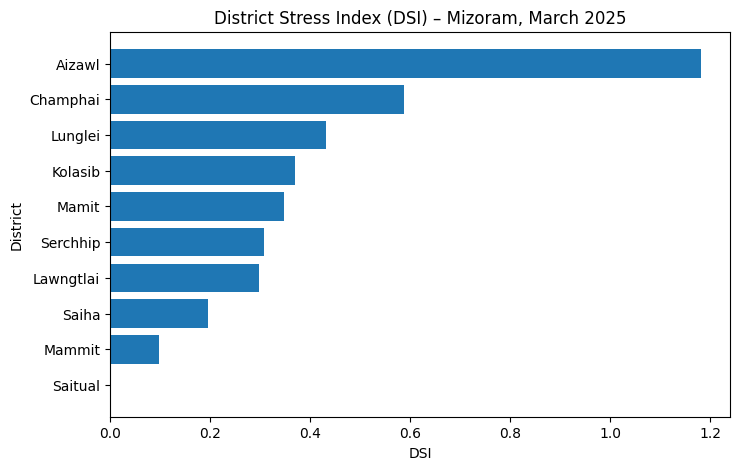

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(mizoram_district_updates['district'], mizoram_district_updates['DSI'])
plt.gca().invert_yaxis()
plt.title("District Stress Index (DSI) – Mizoram, March 2025")
plt.xlabel("DSI")
plt.ylabel("District")
plt.show()

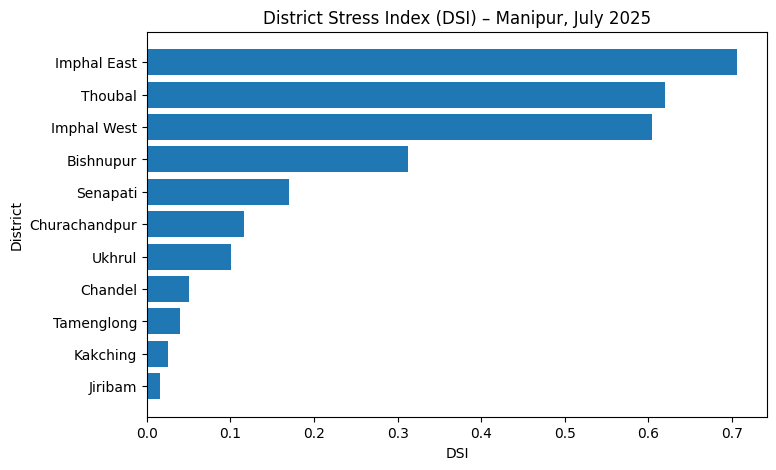

In [32]:
plt.figure(figsize=(8,5))
plt.barh(manipur_district_updates['district'], manipur_district_updates['DSI'])
plt.gca().invert_yaxis()
plt.title("District Stress Index (DSI) – Manipur, July 2025")
plt.xlabel("DSI")
plt.ylabel("District")
plt.show()

In [33]:
buis_pivot = buis_table.pivot_table(
    index='state',
    columns='month',
    values='BUIS'
)

buis_pivot.head()

month,2025-03,2025-04,2025-05,2025-06,2025-07,2025-09,2025-10,2025-11,2025-12
state,,,,,,,,,
Andaman and Nicobar Islands,1.175331,1.193159,0.823993,0.845299,1.229684,1.197072,0.649628,0.792250,1.093584
Andhra Pradesh,0.977137,1.474536,1.213038,1.231965,0.809789,0.546337,0.863094,0.956310,0.927795
Arunachal Pradesh,0.919966,1.041177,1.032475,0.887394,1.049507,0.962234,0.782220,1.322016,1.003011
Assam,0.851084,1.279030,0.767836,0.655510,0.871608,0.902627,1.227900,1.046017,1.398389
Bihar,1.403054,1.462245,1.014743,0.908634,1.110046,0.683788,0.496437,0.744182,1.176872


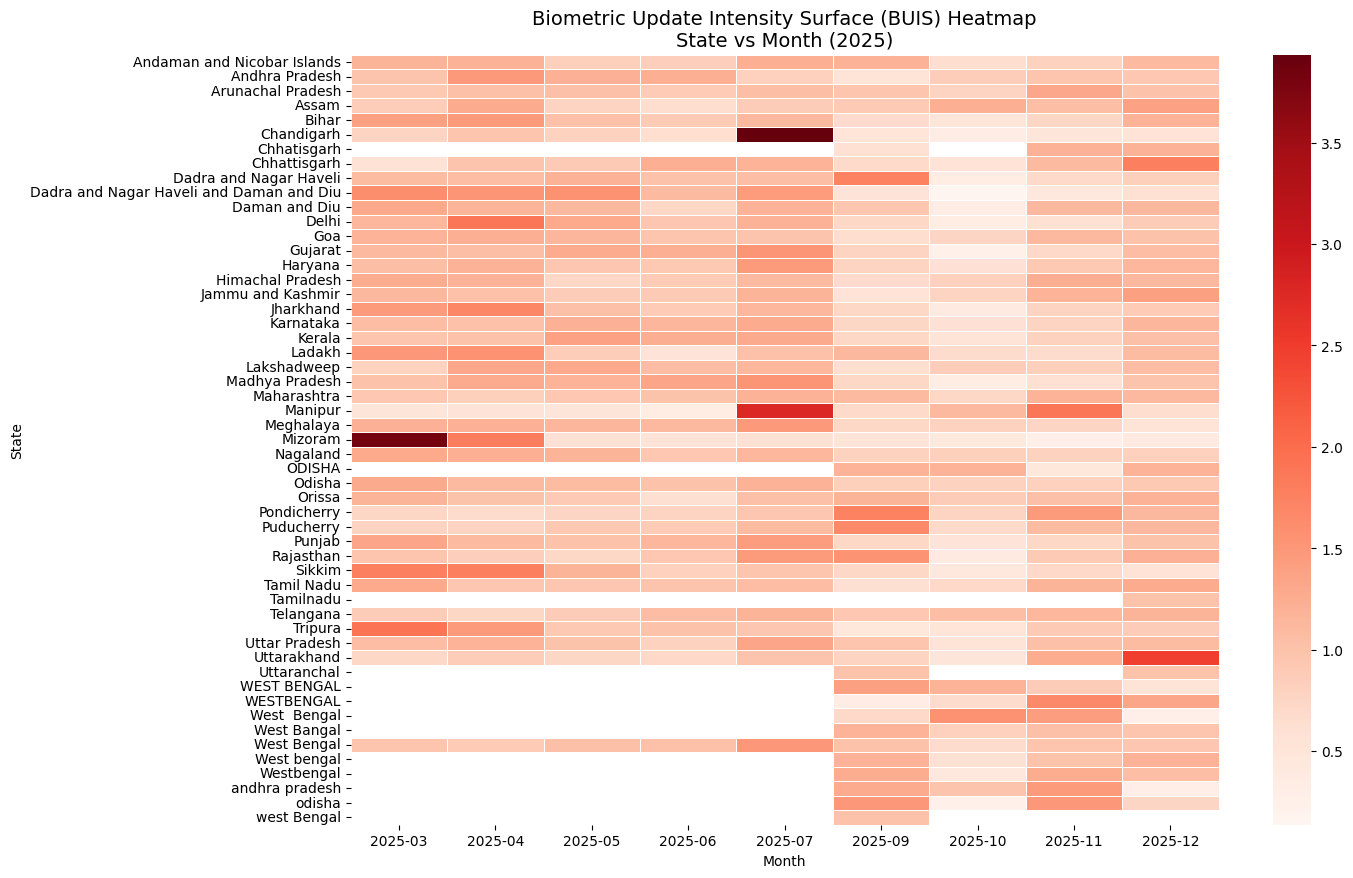

In [34]:
import seaborn as sns

plt.figure(figsize=(14,10))
sns.heatmap(buis_pivot, cmap="Reds", linewidths=0.5, annot=False)

plt.title("Biometric Update Intensity Surface (BUIS) Heatmap\nState vs Month (2025)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("State")

plt.show()